# Case design analysis

Experimental case selection and protocol design for the human–AI decision support study.

## Design target
- 18 scored cases + 2 practice cases
- Within-subject protocols: `no_ai`, `ai_first`, `human_first`
- Case stratification: difficulty tier × AI correctness
- Counterbalanced protocol assignment across participant groups

## Write policy
This notebook is intentionally conservative.

- `artifacts/frozen/` is **never written** by this notebook.
- If `artifacts/frozen/cases.lock.json` exists, the notebook runs in **frozen read-only audit mode**.
- In frozen read-only mode, official cases are loaded from `artifacts/frozen/final_cases.csv`, `practice_cases.csv`, and `protocol_rotation.csv`.
- The deterministic selection code is retained for provenance only. After freezing, the frozen files are the source of truth because those are the cases used in the deployed experiment.
- Build writes are disabled by default. If no frozen lock exists and `WRITE_BUILD_ARTIFACTS=True`, outputs are written only to `artifacts/build/`.

In [1]:
import os
import sys
import json
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current] + list(current.parents):
        if (candidate / "artifacts").exists() and (candidate / "codes").exists():
            return candidate
    raise RuntimeError("Could not locate repository root. Run from inside the capstone repo.")

ROOT = find_repo_root()
ARTIFACTS = ROOT / "artifacts"
BUILD_DIR = ARTIFACTS / "build"
FROZEN_DIR = ARTIFACTS / "frozen"
FIGS_DIR = ROOT / "codes" / "visualizations"

BUILD_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# Safety default: no generated case artifacts are written unless explicitly enabled
# Even if enabled, this notebook never writes to artifacts/frozen/
WRITE_BUILD_ARTIFACTS = False

if str(ROOT / "codes") not in sys.path:
    sys.path.append(str(ROOT / "codes"))

from feature_config import FEATURES, TARGET

np.random.seed(42)
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

print("ROOT       :", ROOT)
print("BUILD_DIR  :", BUILD_DIR)
print("FROZEN_DIR :", FROZEN_DIR)
print("FIGS_DIR   :", FIGS_DIR)
print("Working    :", Path.cwd())
print("WRITE_BUILD_ARTIFACTS:", WRITE_BUILD_ARTIFACTS)

ROOT       : /Users/annaasatryan/Desktop/capstone
BUILD_DIR  : /Users/annaasatryan/Desktop/capstone/artifacts/build
FROZEN_DIR : /Users/annaasatryan/Desktop/capstone/artifacts/frozen
FIGS_DIR   : /Users/annaasatryan/Desktop/capstone/codes/visualizations
Working    : /Users/annaasatryan/Desktop/capstone/codes/notebooks
WRITE_BUILD_ARTIFACTS: False


## 1. Freeze guard and official frozen-artifact loading

In [2]:
LOCK_PATH = FROZEN_DIR / "cases.lock.json"
READ_ONLY_FROZEN = LOCK_PATH.exists()

if READ_ONLY_FROZEN:
    locked = json.loads(LOCK_PATH.read_text())
    WRITE_BUILD_ARTIFACTS = False

    print("Frozen lock detected — running in read-only audit mode.")
    print(f"git commit: {str(locked.get('git_commit', 'unknown'))[:12]}")
    print(f"locked at : {locked.get('created_at', 'unknown')}")
    print("Frozen artifacts are the official source of truth.")
else:
    locked = {}
    print("No frozen lock detected.")
    if WRITE_BUILD_ARTIFACTS:
        print("Build writes are enabled. Outputs may refresh artifacts/build/.")
    else:
        print("Audit mode: build writes are disabled. Set WRITE_BUILD_ARTIFACTS=True only if intentional.")

if READ_ONLY_FROZEN:
    frozen_required = {
        "final_cases": FROZEN_DIR / "final_cases.csv",
        "practice_cases": FROZEN_DIR / "practice_cases.csv",
        "protocol_rotation": FROZEN_DIR / "protocol_rotation.csv",
    }

    missing = [name for name, path in frozen_required.items() if not path.exists()]
    if missing:
        raise FileNotFoundError(f"Frozen lock exists, but missing frozen artifacts: {missing}")

    FROZEN_FINAL_CASES = pd.read_csv(frozen_required["final_cases"])
    FROZEN_PRACTICE_CASES = pd.read_csv(frozen_required["practice_cases"])
    FROZEN_PROTOCOL_ROTATION = pd.read_csv(frozen_required["protocol_rotation"])

    print("\nLoaded frozen official case artifacts:")
    print(f"  final_cases      : {FROZEN_FINAL_CASES.shape}")
    print(f"  practice_cases   : {FROZEN_PRACTICE_CASES.shape}")
    print(f"  protocol_rotation: {FROZEN_PROTOCOL_ROTATION.shape}")
else:
    FROZEN_FINAL_CASES = None
    FROZEN_PRACTICE_CASES = None
    FROZEN_PROTOCOL_ROTATION = None

Frozen lock detected — running in read-only audit mode.
git commit: 9fcf633ba08f
locked at : 2026-04-25T00:00:00+00:00
Frozen artifacts are the official source of truth.

Loaded frozen official case artifacts:
  final_cases      : (18, 20)
  practice_cases   : (2, 25)
  protocol_rotation: (3, 5)


## 2. Load candidate pool

In frozen/read-only mode the candidate pool is read from `artifacts/frozen/` so diagnostics match the locked experiment snapshot. Otherwise it is read from `artifacts/build/`.

In [3]:
pool_dir = FROZEN_DIR if READ_ONLY_FROZEN else BUILD_DIR
pool_path = pool_dir / "candidate_pool_scored.parquet"

if not pool_path.exists():
    raise FileNotFoundError(
        f"Missing candidate pool: {pool_path}\n"
        "Run modeling.ipynb first, or check that frozen artifacts exist."
    )

df = pd.read_parquet(pool_path)
df["pred_prob"] = df["pred_prob"].clip(1e-6, 1 - 1e-6)

print(f"Loaded: {pool_path}")
print("Shape:", df.shape)
print("Default rate:", round(float(df["y_true"].mean()), 4))
print("Difficulty tier counts:")
print(df["difficulty_tier"].value_counts().sort_index())

Loaded: /Users/annaasatryan/Desktop/capstone/artifacts/frozen/candidate_pool_scored.parquet
Shape: (479744, 14)
Default rate: 0.2288
Difficulty tier counts:
difficulty_tier
easy      241081
hard       63224
medium    175439
Name: count, dtype: int64


## 3. Feature engineering for case-selection diagnostics

In [4]:
df["model_pred_class"] = (df["pred_prob"] >= 0.5).astype(int)
df["correct"] = (df["model_pred_class"] == df["y_true"]).astype(int)

df["confidence"] = np.where(
    df["pred_prob"] >= 0.5,
    df["pred_prob"],
    1 - df["pred_prob"],
)

df["conf_bin"] = (
    df.groupby("difficulty_tier", observed=True)["confidence"]
    .transform(lambda x: pd.qcut(x, q=2, labels=["low", "high"], duplicates="drop"))
)

print("=== ACCURACY BY DIFFICULTY ===")
print(df.groupby("difficulty_tier", observed=True)["correct"].mean().round(4))

print("\n=== CONFIDENCE BY DIFFICULTY ===")
print(df.groupby("difficulty_tier", observed=True)["confidence"].mean().round(4))

=== ACCURACY BY DIFFICULTY ===
difficulty_tier
easy      0.8629
hard      0.5888
medium    0.7014
Name: correct, dtype: float64

=== CONFIDENCE BY DIFFICULTY ===
difficulty_tier
easy      0.8877
hard      0.6284
medium    0.7334
Name: confidence, dtype: float64


## 4. Confidence-accuracy alignment diagnostic

In [5]:
gap = (
    df.loc[df["correct"] == 1, "confidence"].mean()
    - df.loc[df["correct"] == 0, "confidence"].mean()
)

print(f"Mean confidence when correct   : {df.loc[df['correct'] == 1, 'confidence'].mean():.4f}")
print(f"Mean confidence when incorrect : {df.loc[df['correct'] == 0, 'confidence'].mean():.4f}")
print(f"Confidence gap (correct - wrong): {gap:.4f}")

Mean confidence when correct   : 0.8170
Mean confidence when incorrect : 0.7313
Confidence gap (correct - wrong): 0.0857


## 5. Directional error analysis

In [6]:
df["fp"] = ((df["model_pred_class"] == 1) & (df["y_true"] == 0)).astype(int)
df["fn"] = ((df["model_pred_class"] == 0) & (df["y_true"] == 1)).astype(int)

print("=== ERROR TYPES BY DIFFICULTY ===")
print(df.groupby("difficulty_tier", observed=True)[["fp", "fn"]].mean().round(4))

=== ERROR TYPES BY DIFFICULTY ===
                     fp      fn
difficulty_tier                
easy             0.0000  0.1371
hard             0.1898  0.2214
medium           0.0434  0.2552


## 6. Normative decision benchmark

Decision threshold tau: 0.1667
Approval rate — model at 0.5 : 0.9217
Approval rate — optimal tau  : 0.4408
Model-optimal disagreement   : 0.4809

=== MODEL-OPTIMAL AGREEMENT BY DIFFICULTY ===
difficulty_tier
easy      0.7987
hard      0.3758
medium    0.1865
Name: model_optimal, dtype: float64


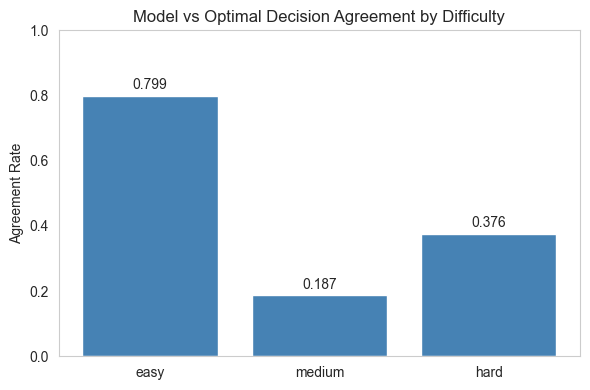

In [7]:
C_FN = 5
C_FP = 1
tau = C_FP / (C_FP + C_FN)

df["model_decision"] = (df["pred_prob"] < 0.5).astype(int)  # 1 = approve
df["optimal_decision"] = (df["pred_prob"] < tau).astype(int)
df["model_optimal"] = (df["model_decision"] == df["optimal_decision"]).astype(int)

print(f"Decision threshold tau: {tau:.4f}")
print(f"Approval rate — model at 0.5 : {df['model_decision'].mean():.4f}")
print(f"Approval rate — optimal tau  : {df['optimal_decision'].mean():.4f}")
print(f"Model-optimal disagreement   : {(df['model_decision'] != df['optimal_decision']).mean():.4f}")

print("\n=== MODEL-OPTIMAL AGREEMENT BY DIFFICULTY ===")
print(df.groupby("difficulty_tier", observed=True)["model_optimal"].mean().round(4))

fig, ax = plt.subplots(figsize=(6, 4))
order = ["easy", "medium", "hard"]
vals = [df.loc[df["difficulty_tier"] == t, "model_optimal"].mean() for t in order]
ax.bar(order, vals, color="steelblue")
ax.set_title("Model vs Optimal Decision Agreement by Difficulty")
ax.set_ylabel("Agreement Rate")
ax.set_ylim(0, 1)
ax.grid(False)
for i, v in enumerate(vals):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)
plt.tight_layout()
fig.savefig(FIGS_DIR / "normative_agreement.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Experimental design

Each participant completed exactly 18 scored trials, one per selected case. Across the three participant groups, each case cluster is observed under every protocol.

Protocol assignment is counterbalanced:
- Group 1: block 1 → `no_ai`; block 2 → `human_first`; block 3 → `ai_first`
- Group 2: block 1 → `human_first`; block 2 → `ai_first`; block 3 → `no_ai`
- Group 3: block 1 → `ai_first`; block 2 → `no_ai`; block 3 → `human_first`

Case stratification uses 3 difficulty tiers × 2 AI-correctness states = 6 cells, with 3 cases per cell.

**Frozen-mode rule:** if the experiment is locked, the frozen case files are official. The selection code below is retained for provenance but does not define the official case set after freezing.

## 8. Deterministic selection algorithm retained for provenance

In [8]:
N_PER_CELL = 3

df_pool = df[
    (df["pred_prob"] > 0.05)
    & (df["pred_prob"] < 0.95)
    & (df["difficulty_tier"].notna())
    & (df["purpose"] != "other")
].copy()

_tier_order = pd.CategoricalDtype(["easy", "medium", "hard"], ordered=True)
df_pool["difficulty_tier"] = df_pool["difficulty_tier"].astype(_tier_order)

print(f"Case pool after filtering: {len(df_pool):,}")
print(df_pool.groupby(["difficulty_tier", "correct"], observed=True).size().unstack(fill_value=0))

def sample_cell(df_source, tier, correct, n, already_selected_probs=None, min_dist=0.02):
    subset = df_source[
        (df_source["difficulty_tier"] == tier)
        & (df_source["correct"] == correct)
    ].copy()

    if len(subset) <= n:
        return subset

    if already_selected_probs is None:
        already_selected_probs = []

    if tier == "hard":
        subset = subset.sort_values(["pred_prob", "case_id"], ascending=[False, True])
    elif tier == "easy" and correct == 1:
        subset = subset.sort_values(["pred_prob", "case_id"], ascending=[True, True])
    elif "model_optimal" in subset.columns and subset["model_optimal"].nunique() > 1:
        subset = subset.sort_values(["model_optimal", "pred_prob", "case_id"])
    else:
        subset = subset.sort_values(["pred_prob", "case_id"])

    selected_rows = []
    selected_probs = list(already_selected_probs)
    used_purposes = set()

    for _, row in subset.iterrows():
        prob = row["pred_prob"]
        if any(abs(prob - p) < min_dist for p in selected_probs):
            continue
        if row["purpose"] not in used_purposes:
            selected_rows.append(row)
            selected_probs.append(prob)
            used_purposes.add(row["purpose"])
        if len(selected_rows) >= n:
            break

    if len(selected_rows) < n:
        selected_index = [r.name for r in selected_rows]
        remaining = subset.drop(index=selected_index)
        for _, row in remaining.iterrows():
            prob = row["pred_prob"]
            if any(abs(prob - p) < min_dist for p in selected_probs):
                continue
            selected_rows.append(row)
            selected_probs.append(prob)
            if len(selected_rows) >= n:
                break

    if len(selected_rows) < n:
        selected_index = [r.name for r in selected_rows]
        remaining = subset.drop(index=selected_index).sort_values(["pred_prob", "case_id"])
        for _, row in remaining.iterrows():
            selected_rows.append(row)
            if len(selected_rows) >= n:
                break

    return pd.DataFrame(selected_rows)

cells_order = [
    ("easy", 1),
    ("hard", 1),
    ("hard", 0),
    ("medium", 1),
    ("medium", 0),
    ("easy", 0),
]

all_selected_probs = []
sampled = []

for tier, correct in cells_order:
    cell_df = sample_cell(
        df_pool,
        tier,
        correct,
        N_PER_CELL,
        already_selected_probs=all_selected_probs,
        min_dist=0.02,
    )
    all_selected_probs.extend(cell_df["pred_prob"].tolist())
    sampled.append(cell_df)

generated_cases = (
    pd.concat(sampled)
    .drop_duplicates(subset=["case_id"])
    .reset_index(drop=True)
)
generated_cases["case_position"] = generated_cases.index + 1
generated_cases["difficulty_tier"] = generated_cases["difficulty_tier"].astype(_tier_order)

print(f"\nGenerated by selection algorithm: {len(generated_cases)} cases")
print(pd.crosstab(generated_cases["difficulty_tier"], generated_cases["correct"]))

Case pool after filtering: 417,304
correct              0       1
difficulty_tier               
easy             29621  168249
medium           48155  112787
hard             24215   34277

Generated by selection algorithm: 18 cases
correct          0  1
difficulty_tier      
easy             3  3
medium           3  3
hard             3  3


## 9. Protocol assignment for generated cases

In [9]:
np.random.seed(42)
block_labels = ["block_1", "block_2", "block_3"]

assignments = []
for (diff, corr), group in generated_cases.groupby(["difficulty_tier", "correct"], observed=True):
    group_shuffled = group.sample(frac=1, random_state=42).reset_index(drop=True)
    assert len(group_shuffled) == 3, (
        f"Expected 3 cases for ({diff}, correct={corr}), got {len(group_shuffled)}"
    )
    for i, block in enumerate(block_labels):
        row = group_shuffled.iloc[i].copy()
        row["block"] = block
        assignments.append(row)

generated_cases = pd.DataFrame(assignments).reset_index(drop=True)
generated_cases["difficulty_tier"] = generated_cases["difficulty_tier"].astype(_tier_order)
generated_cases = generated_cases.sort_values(["block", "difficulty_tier", "correct"]).reset_index(drop=True)
generated_cases["case_position"] = generated_cases.index + 1

generated_protocol_rotation = pd.DataFrame({
    "participant_group": ["group_1", "group_2", "group_3"],
    "block_1_protocol": ["no_ai", "human_first", "ai_first"],
    "block_2_protocol": ["human_first", "ai_first", "no_ai"],
    "block_3_protocol": ["ai_first", "no_ai", "human_first"],
    "target_n": [33, 33, 34],
})

print("=== GENERATED PROTOCOL ROTATION TABLE ===\n")
print(generated_protocol_rotation.to_string(index=False))

=== GENERATED PROTOCOL ROTATION TABLE ===

participant_group block_1_protocol block_2_protocol block_3_protocol  target_n
          group_1            no_ai      human_first         ai_first        33
          group_2      human_first         ai_first            no_ai        33
          group_3         ai_first            no_ai      human_first        34


## 10. Choose official artifacts for audit

This is the important fix.

- In frozen mode, audit `artifacts/frozen/*.csv`.
- Without a frozen lock, audit the generated cases/protocol rotation.

In [10]:
EXPORT_COLS = [
    "case_id",
    "case_position",
    "block",
    "loan_amnt",
    "term",
    "int_rate",
    "dti",
    "revol_util",
    "credit_history_years",
    "home_ownership",
    "purpose",
    "log_annual_inc",
    "pred_prob",
    "y_true",
    "correct",
    "confidence",
    "difficulty_tier",
    "difficulty_score",
    "conf_bin",
    "model_optimal",
]

generated_final_cases = generated_cases[[c for c in EXPORT_COLS if c in generated_cases.columns]].copy()

if READ_ONLY_FROZEN:
    official_final_cases = FROZEN_FINAL_CASES.copy()
    official_practice_cases = FROZEN_PRACTICE_CASES.copy()
    official_protocol_rotation = FROZEN_PROTOCOL_ROTATION.copy()
    official_source = "artifacts/frozen/"

    generated_ids = generated_final_cases["case_id"].astype(str).tolist()
    frozen_ids = official_final_cases["case_id"].astype(str).tolist()
    print("Diagnostic only: generated case_id sequence matches frozen:", generated_ids == frozen_ids)
    if generated_ids != frozen_ids:
        print("Note: frozen case files remain official because they were used in the deployed experiment.")
else:
    official_final_cases = generated_final_cases.copy()
    official_practice_cases = None
    official_protocol_rotation = generated_protocol_rotation.copy()
    official_source = "generated selection in this notebook"

print(f"\nOfficial audit source: {official_source}")
print("Official final_cases shape:", official_final_cases.shape)
print("Official protocol_rotation shape:", official_protocol_rotation.shape)
if official_practice_cases is not None:
    print("Official practice_cases shape:", official_practice_cases.shape)

Diagnostic only: generated case_id sequence matches frozen: False
Note: frozen case files remain official because they were used in the deployed experiment.

Official audit source: artifacts/frozen/
Official final_cases shape: (18, 20)
Official protocol_rotation shape: (3, 5)
Official practice_cases shape: (2, 25)


## 11. Design verification on official case artifacts

In [11]:
def validate_protocol_rotation(rotation: pd.DataFrame) -> None:
    rotation = rotation.copy()
    required = {"participant_group", "block_1_protocol", "block_2_protocol", "block_3_protocol"}
    missing = required - set(rotation.columns)
    assert not missing, f"Protocol rotation missing required columns: {missing}"

    expected_groups = {"group_1", "group_2", "group_3"}
    expected_protocols = {"no_ai", "human_first", "ai_first"}

    assert len(rotation) == 3, "Must have exactly 3 participant groups"
    assert set(rotation["participant_group"]) == expected_groups, "Participant groups must be group_1, group_2, group_3"

    for col in ["block_1_protocol", "block_2_protocol", "block_3_protocol"]:
        assert set(rotation[col]) == expected_protocols, f"{col} must contain exactly {expected_protocols}"

    for _, row in rotation.iterrows():
        group_protocols = {row["block_1_protocol"], row["block_2_protocol"], row["block_3_protocol"]}
        assert group_protocols == expected_protocols, (
            f"Group {row['participant_group']} does not have all 3 protocols"
        )

def validate_final_cases(final_cases: pd.DataFrame) -> None:
    final_cases = final_cases.copy()
    final_cases["difficulty_tier"] = final_cases["difficulty_tier"].astype(
        pd.CategoricalDtype(["easy", "medium", "hard"], ordered=True)
    )

    assert len(final_cases) == 18, f"Expected 18 final cases, got {len(final_cases)}"
    assert final_cases["case_id"].is_unique, "case_id values must be unique"
    assert set(final_cases["block"]) == {"block_1", "block_2", "block_3"}, "Must have exactly 3 blocks"
    assert (final_cases.groupby("block", observed=True).size() == 6).all(), "Each block must have exactly 6 cases"

    cell_counts = final_cases.groupby(["difficulty_tier", "correct"], observed=True).size()
    assert (cell_counts == N_PER_CELL).all(), (
        f"Not exactly {N_PER_CELL} cases per difficulty×correct cell:\n{cell_counts}"
    )

    ct_block_diff = pd.crosstab(final_cases["block"], final_cases["difficulty_tier"])
    assert (ct_block_diff == 2).all().all(), f"Block × Difficulty not balanced:\n{ct_block_diff}"

    ct_block_corr = pd.crosstab(final_cases["block"], final_cases["correct"])
    assert (ct_block_corr == 3).all().all(), f"Block × Correctness not balanced:\n{ct_block_corr}"

    for block in ["block_1", "block_2", "block_3"]:
        sub = final_cases[final_cases["block"] == block]
        ct = pd.crosstab(sub["difficulty_tier"], sub["correct"])
        assert (ct == 1).all().all(), f"{block} must have exactly 1 case per difficulty × correctness cell"

    required = [
        "case_id",
        "pred_prob",
        "y_true",
        "difficulty_tier",
        "difficulty_score",
        "correct",
        "block",
    ]
    bad = [col for col in required if col not in final_cases.columns or final_cases[col].isna().any()]
    assert not bad, f"Missing or null required fields: {bad}"

    assert (final_cases["purpose"] != "other").all(), "Selected case has purpose == 'other'"
    assert final_cases["pred_prob"].between(0.05, 0.95, inclusive="neither").all(), (
        f"pred_prob outside (0.05, 0.95): min={final_cases['pred_prob'].min():.4f}, "
        f"max={final_cases['pred_prob'].max():.4f}"
    )

    if "dti" in final_cases.columns:
        assert (final_cases["dti"] <= 60).all(), (
            f"DTI out of reasonable display range: max={final_cases['dti'].max():.1f}"
        )

    print("Block × Difficulty:")
    print(ct_block_diff)
    print("\nBlock × Correctness:")
    print(ct_block_corr)
    print("\nDifficulty × Correctness:")
    print(pd.crosstab(final_cases["difficulty_tier"], final_cases["correct"]))
    print("\nCases per block:", final_cases["block"].value_counts().sort_index().to_dict())
    print("y_true balance:", final_cases["y_true"].value_counts().to_dict())
    print("\nOfficial final-case design checks passed.")

validate_protocol_rotation(official_protocol_rotation)
validate_final_cases(official_final_cases)

Block × Difficulty:
difficulty_tier  easy  medium  hard
block                              
block_1             2       2     2
block_2             2       2     2
block_3             2       2     2

Block × Correctness:
correct  0  1
block        
block_1  3  3
block_2  3  3
block_3  3  3

Difficulty × Correctness:
correct          0  1
difficulty_tier      
easy             3  3
medium           3  3
hard             3  3

Cases per block: {'block_1': 6, 'block_2': 6, 'block_3': 6}
y_true balance: {1: 9, 0: 9}

Official final-case design checks passed.


## 12. Distribution checks on official final cases

In [12]:
cases_for_summary = official_final_cases.copy()
cases_for_summary["difficulty_tier"] = cases_for_summary["difficulty_tier"].astype(
    pd.CategoricalDtype(["easy", "medium", "hard"], ordered=True)
)

print("=== OFFICIAL CASE DISTRIBUTION ===\n")
print("By difficulty:")
print(cases_for_summary["difficulty_tier"].value_counts().sort_index())

print("\nBy correctness:")
print(cases_for_summary["correct"].value_counts().sort_index())

print("\nBy block:")
print(cases_for_summary["block"].value_counts().sort_index())

print("\nCross-tab: difficulty × correctness")
print(pd.crosstab(cases_for_summary["difficulty_tier"], cases_for_summary["correct"]))

print("\nPredicted probability by cell:")
print(
    cases_for_summary.groupby(["difficulty_tier", "correct"], observed=True)["pred_prob"]
    .agg(["min", "mean", "max"])
    .round(3)
)

if "confidence" in cases_for_summary.columns:
    print("\nConfidence by cell:")
    print(
        cases_for_summary.groupby(["difficulty_tier", "correct"], observed=True)["confidence"]
        .agg(["min", "mean", "max"])
        .round(3)
    )

print("\n=== PROBABILITY SUMMARY ===")
print(cases_for_summary["pred_prob"].describe())

=== OFFICIAL CASE DISTRIBUTION ===

By difficulty:
difficulty_tier
easy      6
medium    6
hard      6
Name: count, dtype: int64

By correctness:
correct
0    9
1    9
Name: count, dtype: int64

By block:
block
block_1    6
block_2    6
block_3    6
Name: count, dtype: int64

Cross-tab: difficulty × correctness
correct          0  1
difficulty_tier      
easy             3  3
medium           3  3
hard             3  3

Predicted probability by cell:
                           min   mean    max
difficulty_tier correct                     
easy            0        0.333  0.367  0.397
                1        0.055  0.077  0.102
medium          0        0.234  0.266  0.296
                1        0.169  0.189  0.210
hard            0        0.779  0.836  0.900
                1        0.858  0.909  0.946

Confidence by cell:
                           min   mean    max
difficulty_tier correct                     
easy            0        0.603  0.633  0.667
                1        0.89

## 13. Expected-cost baselines for official 18-case set

In [13]:
def compute_cost(decisions, y_true, c_fn=5, c_fp=1):
    decisions = np.asarray(decisions)
    y_true = np.asarray(y_true)
    fn = ((decisions == 1) & (y_true == 1)).sum() * c_fn
    fp = ((decisions == 0) & (y_true == 0)).sum() * c_fp
    return (fn + fp) / len(y_true)

y = cases_for_summary["y_true"].values

always_approve = np.ones(len(cases_for_summary), dtype=int)
always_reject = np.zeros(len(cases_for_summary), dtype=int)
model_05 = (cases_for_summary["pred_prob"] < 0.5).astype(int).values
model_tau = (cases_for_summary["pred_prob"] < tau).astype(int).values

rng = np.random.default_rng(42)
random_decision = rng.binomial(1, 0.5, len(cases_for_summary))

print("=== EXPECTED COST PER CASE — OFFICIAL SELECTED CASE SET ===\n")
print(f"Always approve : {compute_cost(always_approve, y):.3f}")
print(f"Always reject  : {compute_cost(always_reject, y):.3f}")
print(f"Model at 0.5   : {compute_cost(model_05, y):.3f}")
print(f"Optimal at tau : {compute_cost(model_tau, y):.3f}")
print(f"Random         : {compute_cost(random_decision, y):.3f}")

=== EXPECTED COST PER CASE — OFFICIAL SELECTED CASE SET ===

Always approve : 2.500
Always reject  : 0.500
Model at 0.5   : 1.833
Optimal at tau : 0.333
Random         : 1.944


## 14. Full candidate-pool difficulty interaction diagnostic

=== DIFFICULTY × CORRECTNESS INTERACTION — FULL CANDIDATE POOL ===

                              n  avg_pred  avg_conf  model_opt
difficulty_tier correct                                       
easy            0         33044     0.137     0.863      0.672
                1        208037     0.108     0.892      0.819
hard            0         26000     0.459     0.615      0.462
                1         37224     0.419     0.638      0.316
medium          0         52384     0.312     0.706      0.210
                1        123055     0.262     0.745      0.177


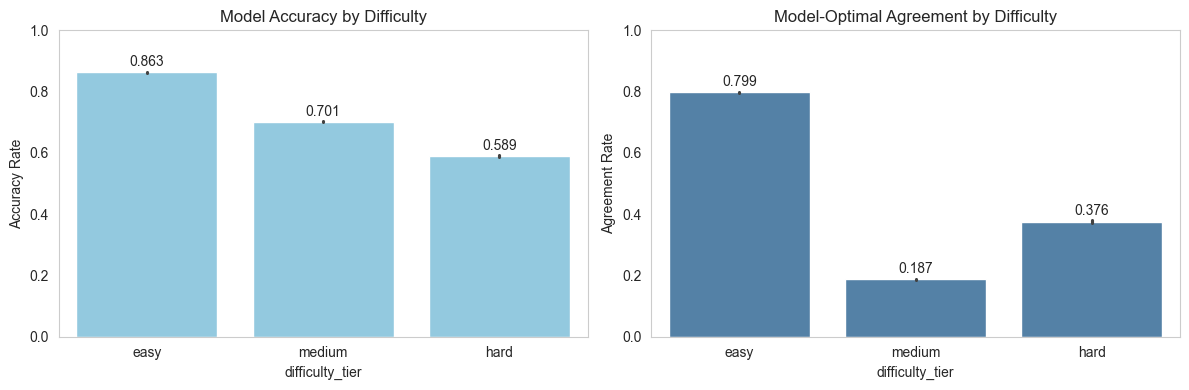

In [14]:
print("=== DIFFICULTY × CORRECTNESS INTERACTION — FULL CANDIDATE POOL ===\n")

interaction = (
    df.groupby(["difficulty_tier", "correct"], observed=True)
    .agg(
        n=("pred_prob", "size"),
        avg_pred=("pred_prob", "mean"),
        avg_conf=("confidence", "mean"),
        model_opt=("model_optimal", "mean"),
    )
    .round(3)
)
print(interaction.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
order = ["easy", "medium", "hard"]

sns.barplot(
    data=df,
    x="difficulty_tier",
    y="correct",
    hue="difficulty_tier",
    palette=["skyblue"],
    ax=axes[0],
    legend=False,
    order=order,
)
axes[0].set_title("Model Accuracy by Difficulty")
axes[0].set_ylabel("Accuracy Rate")
axes[0].set_ylim(0, 1)
axes[0].grid(False)
for bar in axes[0].patches:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, height + 0.02, f"{height:.3f}", ha="center", fontsize=10)

sns.barplot(
    data=df,
    x="difficulty_tier",
    y="model_optimal",
    hue="difficulty_tier",
    palette=["steelblue"],
    ax=axes[1],
    legend=False,
    order=order,
)
axes[1].set_title("Model-Optimal Agreement by Difficulty")
axes[1].set_ylabel("Agreement Rate")
axes[1].set_ylim(0, 1)
axes[1].grid(False)
for bar in axes[1].patches:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2, height + 0.02, f"{height:.3f}", ha="center", fontsize=10)

plt.tight_layout()
fig.savefig(FIGS_DIR / "difficulty_interactions.png", dpi=150, bbox_inches="tight")
plt.show()

## 15. Practice-case audit

In [15]:
if official_practice_cases is None:
    selected_ids = set(official_final_cases["case_id"].tolist())

    practice_safe = df_pool[
        ~df_pool["case_id"].isin(selected_ids)
        & (df_pool["y_true"] == 0)
        & (df_pool["pred_prob"] < 0.06)
        & (df_pool["difficulty_tier"] == "easy")
    ].sample(1, random_state=42)

    practice_risky = df_pool[
        ~df_pool["case_id"].isin(selected_ids)
        & (df_pool["y_true"] == 1)
        & (df_pool["pred_prob"] > 0.55)
        & (df_pool["difficulty_tier"] == "hard")
    ].sample(1, random_state=42)

    official_practice_cases = pd.concat([practice_safe, practice_risky]).reset_index(drop=True)
    official_practice_cases["case_position"] = [-2, -1]
    official_practice_cases["block"] = "practice"

assert len(official_practice_cases) == 2, f"Expected exactly 2 practice cases, got {len(official_practice_cases)}"
overlap = set(official_practice_cases["case_id"]) & set(official_final_cases["case_id"])
assert not overlap, f"Practice cases overlap with final cases: {overlap}"

print("=== OFFICIAL PRACTICE TRIALS ===")
display_cols = [c for c in ["case_id", "pred_prob", "y_true", "difficulty_tier", "purpose", "loan_amnt", "int_rate"] if c in official_practice_cases.columns]
print(official_practice_cases[display_cols].to_string(index=False))
print("\nPractice-case checks passed.")

=== OFFICIAL PRACTICE TRIALS ===
 case_id  pred_prob  y_true difficulty_tier        purpose  loan_amnt  int_rate
  946400   0.059221       0            easy    credit_card       6600      8.39
  934189   0.623978       1            hard small_business      15000     24.99

Practice-case checks passed.


## 16. Optional build writes

In [16]:
if READ_ONLY_FROZEN:
    print("Frozen read-only mode: skipped all writes. artifacts/frozen/ was not modified.")
elif not WRITE_BUILD_ARTIFACTS:
    print("Audit mode: skipped writes. Set WRITE_BUILD_ARTIFACTS=True only to refresh artifacts/build/.")
else:
    official_final_cases.to_csv(BUILD_DIR / "final_cases.csv", index=False)
    official_practice_cases.to_csv(BUILD_DIR / "practice_cases.csv", index=False)
    official_protocol_rotation.to_csv(BUILD_DIR / "protocol_rotation.csv", index=False)

    selection_manifest = {
        "seed": 42,
        "input_candidate_pool": str(BUILD_DIR / "candidate_pool_scored.parquet"),
        "n_final_cases": int(len(official_final_cases)),
        "n_practice_cases": int(len(official_practice_cases)),
        "N_PER_CELL": int(N_PER_CELL),
        "probability_filter": {"min_exclusive": 0.05, "max_exclusive": 0.95},
        "excluded_purpose": "other",
        "cost_ratio": {
            "C_FN": int(C_FN),
            "C_FP": int(C_FP),
            "tau": round(float(tau), 6),
        },
        "sampling_cell_order": [list(c) for c in cells_order],
        "output_paths": {
            "final_cases": str(BUILD_DIR / "final_cases.csv"),
            "practice_cases": str(BUILD_DIR / "practice_cases.csv"),
            "protocol_rotation": str(BUILD_DIR / "protocol_rotation.csv"),
        },
    }

    with open(BUILD_DIR / "selection_manifest.json", "w") as f:
        json.dump(selection_manifest, f, indent=2)

    print("Wrote build artifacts:")
    print(f"  {BUILD_DIR / 'final_cases.csv'}")
    print(f"  {BUILD_DIR / 'practice_cases.csv'}")
    print(f"  {BUILD_DIR / 'protocol_rotation.csv'}")
    print(f"  {BUILD_DIR / 'selection_manifest.json'}")

Frozen read-only mode: skipped all writes. artifacts/frozen/ was not modified.


## 17. Participant-facing case preview

In [ ]:
def dti_label(dti):
    if dti < 15:
        return "LOW"
    if dti < 30:
        return "MODERATE"
    return "HIGH"

def util_label(x):
    if x < 30:
        return "LOW"
    if x < 70:
        return "MODERATE"
    return "HIGH"

def income_label_from_log(log_income):
    income = np.exp(log_income)
    if income < 30000:
        return "LOW"
    if income < 100000:
        return "MEDIUM"
    return "HIGH"

preview_cols = [
    "case_position",
    "block",
    "case_id",
    "difficulty_tier",
    "correct",
    "pred_prob",
    "y_true",
    "loan_amnt",
    "term",
    "int_rate",
    "dti",
    "revol_util",
    "home_ownership",
    "purpose",
    "credit_history_years",
]

preview = official_final_cases[[c for c in preview_cols if c in official_final_cases.columns]].copy()
if "dti" in preview.columns:
    preview["dti_label"] = preview["dti"].map(dti_label)
if "revol_util" in preview.columns:
    preview["util_label"] = preview["revol_util"].map(util_label)
if "log_annual_inc" in official_final_cases.columns:
    preview["income_label"] = official_final_cases["log_annual_inc"].map(income_label_from_log)

print("=== OFFICIAL FINAL CASE PREVIEW ===")
display(preview)

=== OFFICIAL FINAL CASE PREVIEW ===


,case_position,block,case_id,difficulty_tier,correct,pred_prob,y_true,loan_amnt,term,int_rate,dti,revol_util,home_ownership,purpose,credit_history_years,dti_label,util_label,income_label
0,1,block_1,844888,easy,0,0.333333,1,30000,60 months,12.88,21.16,60.1,RENT,debt_consolidation,15.249829,MODERATE,MODERATE,MEDIUM
1,2,block_1,1183988,easy,1,0.054726,0,7200,36 months,7.97,7.96,0.0,MORTGAGE,car,6.083504,LOW,LOW,MEDIUM
2,3,block_1,819669,medium,0,0.234348,1,2000,36 months,15.77,28.78,98.1,OWN,medical,23.915127,MODERATE,HIGH,MEDIUM
3,4,block_1,819289,medium,1,0.168642,0,1000,36 months,13.99,25.31,61.1,MORTGAGE,debt_consolidation,19.249829,MODERATE,MODERATE,MEDIUM
4,5,block_1,1215065,hard,0,0.899569,0,13125,60 months,24.85,39.53,95.5,RENT,debt_consolidation,19.917864,HIGH,HIGH,LOW
5,6,block_1,1263657,hard,1,0.946130,1,18000,60 months,28.72,39.53,96.4,OWN,credit_card,18.253251,HIGH,HIGH,LOW
6,7,block_2,937917,easy,0,0.370370,1,21000,60 months,13.67,9.14,29.9,RENT,small_business,21.333333,LOW,LOW,MEDIUM
7,8,block_2,828575,easy,1,0.074984,0,10000,36 months,9.80,9.56,84.0,MORTGAGE,debt_consolidation,3.915127,LOW,HIGH,MEDIUM
8,9,block_2,1185020,medium,0,0.267119,1,8750,36 months,12.62,29.88,13.4,RENT,debt_consolidation,15.496235,MODERATE,LOW,MEDIUM
9,10,block_2,1121112,medium,1,0.188803,0,32000,60 months,13.99,15.28,68.5,MORTGAGE,credit_card,12.503765,MODERATE,MODERATE,HIGH


## Final notebook status

If the frozen lock exists, the expected final message is:

```text
Frozen read-only mode: skipped all writes. artifacts/frozen/ was not modified.
```

That confirms this notebook is safe to rerun for audit purposes.